# Trabajo Práctico — Series Temporales

## 06 — Modelo VAR conjunto

**Objetivo de este notebook:** modelar la dinámica conjunta de las tres series (ozono, temperatura, radiación solar) con un VAR, aprovechando que están relacionadas físicamente (la radiación solar impulsa la fotoquímica del ozono; la temperatura y la radiación comparten el mismo ciclo diario). Se sigue la misma metodología que se vio en clase (Box-Jenkins multivariado: causalidad de Granger → selección de orden → ajuste → diagnóstico de residuos → IRF → FEVD → pronóstico), con una adaptación explicada abajo.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, coint
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
ordenes = json.loads((PROJECT_ROOT / "data/processed/ordenes_diferenciacion.json").read_text(encoding="utf-8"))

print(f"Filas totales: {len(datos):,}")
print(json.dumps(ordenes, indent=2))

Filas totales: 239,078
{
  "ozono_ppm": {
    "d": 0,
    "D": 1,
    "periodo_estacional": 24
  },
  "temperatura_c": {
    "d": 0,
    "D": 1,
    "periodo_estacional": 24
  },
  "radiacion_ghi_wm2": {
    "d": 0,
    "D": 1,
    "periodo_estacional": 24
  }
}


## 1. ¿Cointegración/VECM, o VAR sobre la serie diferenciada?

En `04_estacionariedad.ipynb` se determinó, con ADF+KPSS+Phillips-Perron, que las tres series son estacionarias **en nivel** (no tienen raíz unitaria: 2 ó 3 de 3 tests lo confirman) y que sólo necesitan diferenciación **estacional** (`D=1`, período 24h) para eliminar el ciclo diario. Esto es distinto del caso clásico de VECM (dos o más series integradas de orden 1, con una combinación lineal estacionaria — "cointegradas"): acá no hay raíz unitaria que cointegrar, hay un ciclo determinístico diario que remover.

Por eso el VAR se ajusta sobre las series diferenciadas estacionalmente (`.diff(24)`), igual que se hizo para el SARIMA en `05_sarima.ipynb` — así el modelo queda consistente entre notebooks. De todas formas, a modo **didáctico** (como se hizo en el ejercicio de la cátedra), se corre el test de cointegración de Engle-Granger sobre las series en nivel, para mostrar por qué no aplicaría un VECM acá.

In [2]:
print("Test de cointegración de Engle-Granger (didáctico, por par de variables, en NIVEL):\n")
for col_a, col_b in itertools.combinations(datos.columns, 2):
    estadistico, pvalor, _ = coint(datos[col_a], datos[col_b])
    conclusion = "cointegradas" if pvalor < 0.05 else "NO cointegradas"
    print(f"  {col_a} <-> {col_b}: estadístico={estadistico:.3f}  p-valor={pvalor:.4f}  -> {conclusion}")

print("\nComo ya se sabía que las series son estacionarias en nivel (no integradas de orden 1),")
print("este resultado es esperable y confirma que un VECM no es el modelo adecuado acá.")

Test de cointegración de Engle-Granger (didáctico, por par de variables, en NIVEL):



  ozono_ppm <-> temperatura_c: estadístico=-28.711  p-valor=0.0000  -> cointegradas


  ozono_ppm <-> radiacion_ghi_wm2: estadístico=-29.382  p-valor=0.0000  -> cointegradas


  temperatura_c <-> radiacion_ghi_wm2: estadístico=-20.116  p-valor=0.0000  -> cointegradas

Como ya se sabía que las series son estacionarias en nivel (no integradas de orden 1),
este resultado es esperable y confirma que un VECM no es el modelo adecuado acá.


## 2. Preparación: diferencia estacional y train/test

Mismo split que en `05_sarima.ipynb` para poder comparar: los últimos 7 días (168 horas) quedan como test.

In [3]:
PERIODO_ESTACIONAL = 24
HORAS_TEST = 24 * 7

datos_diff = datos.diff(PERIODO_ESTACIONAL).dropna()

train = datos_diff.iloc[:-HORAS_TEST]
test = datos_diff.iloc[-HORAS_TEST:]

print(f"Serie diferenciada (D=1, s=24): {len(datos_diff):,} filas")
print(f"Train: {len(train):,} | Test: {len(test):,}")

Serie diferenciada (D=1, s=24): 239,054 filas
Train: 238,886 | Test: 168


## 3. Causalidad de Granger

Matriz de p-valores: fila = variable potencialmente afectada, columna = variable potencialmente causante (en el sentido de Granger: "ayuda a predecir"). Se usa `maxlag=48` (dos días) sobre el train diferenciado.

In [4]:
def grangers_causation_matrix(data, variables, maxlag=48, test="ssr_chi2test"):
    resultado = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for col_causante in variables:
        for col_afectada in variables:
            if col_causante == col_afectada:
                resultado.loc[col_afectada, col_causante] = np.nan
                continue
            test_result = grangercausalitytests(
                data[[col_afectada, col_causante]], maxlag=maxlag, verbose=False
            )
            p_valores = [test_result[lag + 1][0][test][1] for lag in range(maxlag)]
            resultado.loc[col_afectada, col_causante] = min(p_valores)
    resultado.columns = [c + "_x" for c in variables]
    resultado.index = [c + "_y" for c in variables]
    return resultado


matriz_granger = grangers_causation_matrix(train, list(train.columns))
print("Matriz de p-valores de causalidad de Granger (columna causa -> fila, mínimo p-valor entre lags 1-48):\n")
print(matriz_granger.round(4))

Matriz de p-valores de causalidad de Granger (columna causa -> fila, mínimo p-valor entre lags 1-48):

                     ozono_ppm_x  temperatura_c_x  radiacion_ghi_wm2_x
ozono_ppm_y                  NaN              0.0                  0.0
temperatura_c_y              0.0              NaN                  0.0
radiacion_ghi_wm2_y          0.0              0.0                  NaN


## 4. Selección de orden y ajuste

`select_order` prueba varios criterios (AIC, BIC, FPE, HQIC); se usa el orden sugerido por AIC.

In [5]:
modelo = VAR(train)
seleccion_orden = modelo.select_order(maxlags=48)
print(seleccion_orden.summary())

lag_elegido = seleccion_orden.aic
print(f"\nOrden elegido (AIC): {lag_elegido}")

resultado = modelo.fit(lag_elegido)
print(resultado.summary())

C:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        1.840       1.840       6.294       1.840
1       -1.904      -1.903      0.1490      -1.904
2       -1.987      -1.986      0.1371      -1.987
3       -1.995      -1.994      0.1360      -1.995
4       -1.997      -1.996      0.1357      -1.997
5       -1.999      -1.996      0.1355      -1.998
6       -2.000      -1.997      0.1354      -1.999
7       -2.001      -1.998      0.1352      -2.000
8       -2.002      -1.999      0.1351      -2.001
9       -2.003      -1.999      0.1350      -2.002
10      -2.004      -2.000      0.1348      -2.002
11      -2.004      -2.000      0.1348      -2.003
12      -2.004      -2.000      0.1347      -2.003
13      -2.005      -2.000      0.1347      -2.003
14      -2.005      -2.000      0.1346      -2.003
15      -2.005      -1.999      0.1346      -2.004
16      -2.006      -2.000     

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 17, Aug, 2026
Time:                     19:31:04
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -2.75969
Nobs:                     238838.    HQIC:                  -2.77308
Log likelihood:          -684437.    FPE:                  0.0621254
AIC:                     -2.77860    Det(Omega_mle):       0.0620124
--------------------------------------------------------------------
Results for equation ozono_ppm
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                         0.000001         0.000011            0.060           0.952
L1.ozono_ppm                  1.010892         0.002048          493.711           0.000
L1.temperatura_c        

## 5. Diagnóstico de residuos

Normalidad conjunta (Jarque-Bera vía el propio VARResults) y autocorrelación residual por ecuación (ACF + Ljung-Box).

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.706e+06          12.59   0.000  6
----------------------------------------


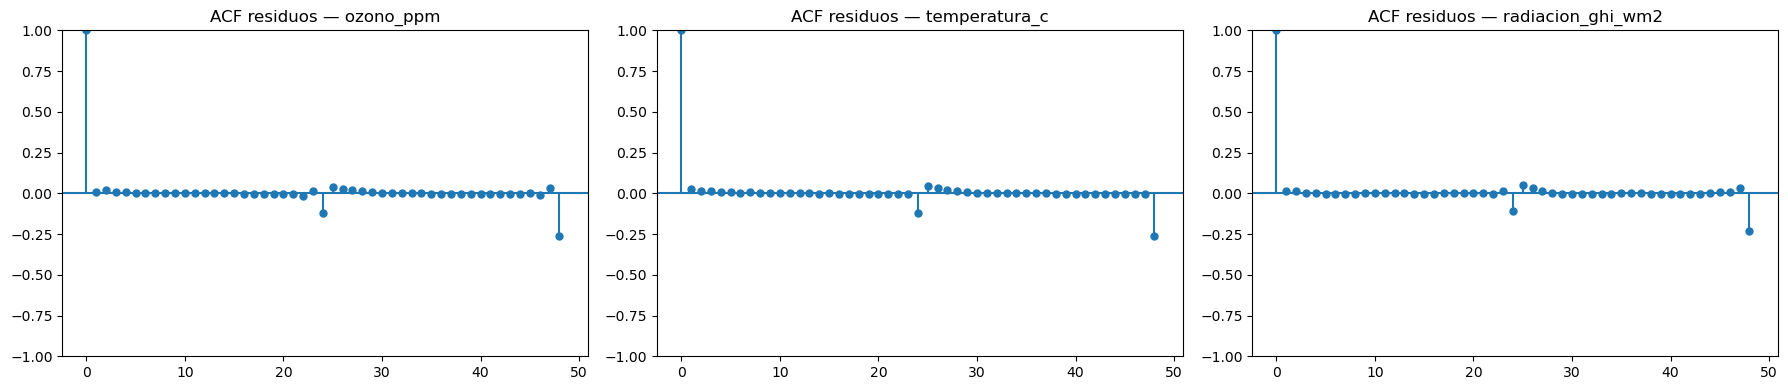

In [6]:
print(resultado.test_normality().summary())

fig, axes = plt.subplots(1, len(train.columns), figsize=(18, 4))
for ax, col in zip(axes, train.columns):
    plot_acf(resultado.resid[col], lags=48, ax=ax)
    ax.set_title(f"ACF residuos — {col}")
plt.tight_layout()
plt.show()

## 6. Funciones impulso-respuesta (IRF)

¿Cómo reacciona cada variable ante un shock de una desviación estándar en otra, a lo largo de las siguientes 24 horas?

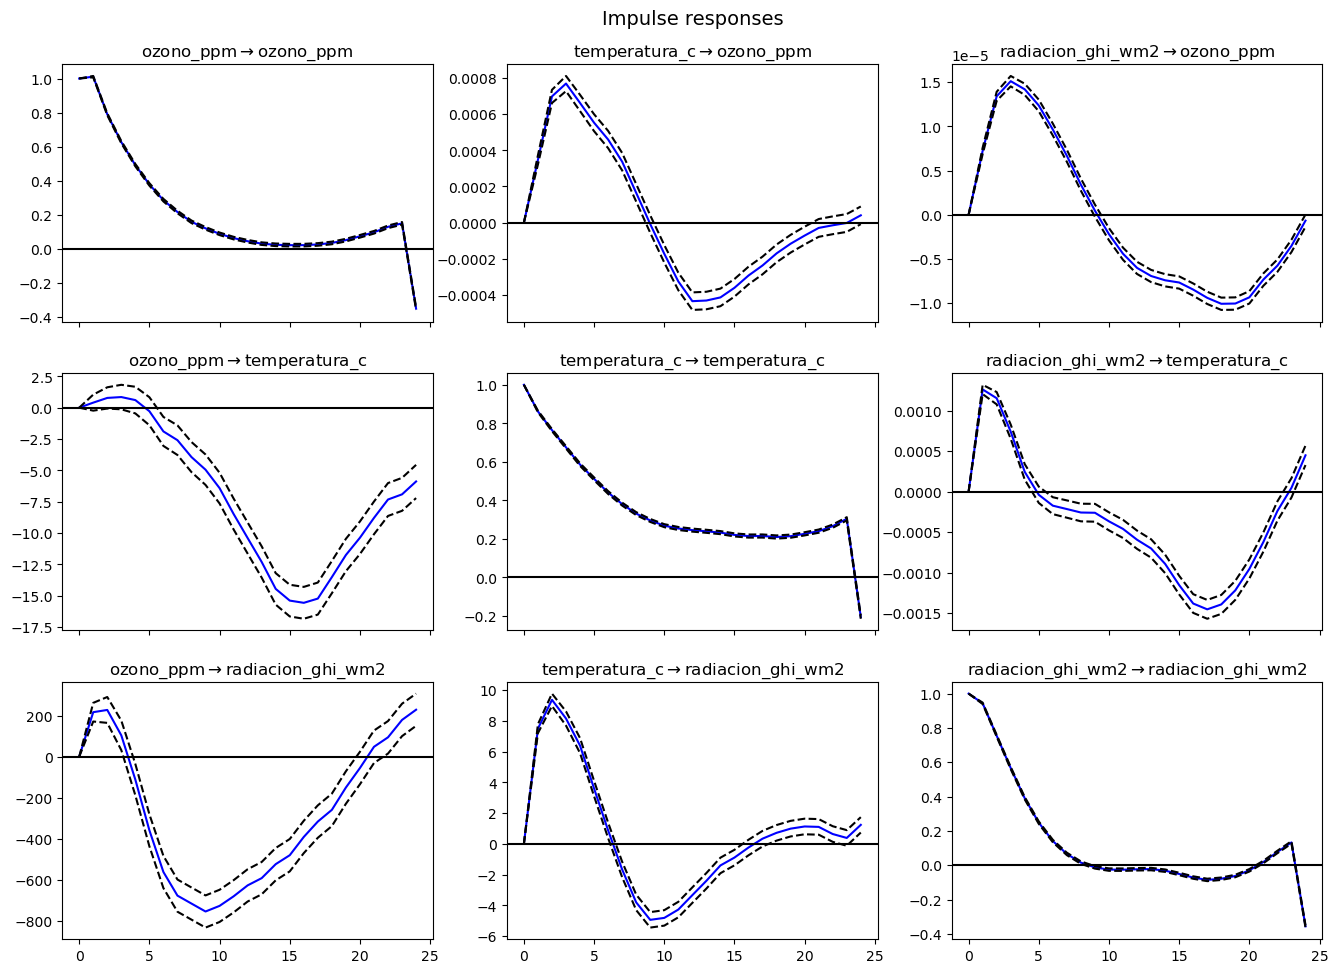

In [7]:
irf = resultado.irf(24)
irf.plot(figsize=(14, 10))
plt.show()

## 7. Descomposición de la varianza del error de pronóstico (FEVD)

¿Qué porción de la varianza del error de pronóstico de cada variable, a distintos horizontes, se explica por shocks en las otras variables (en vez de shocks propios)?

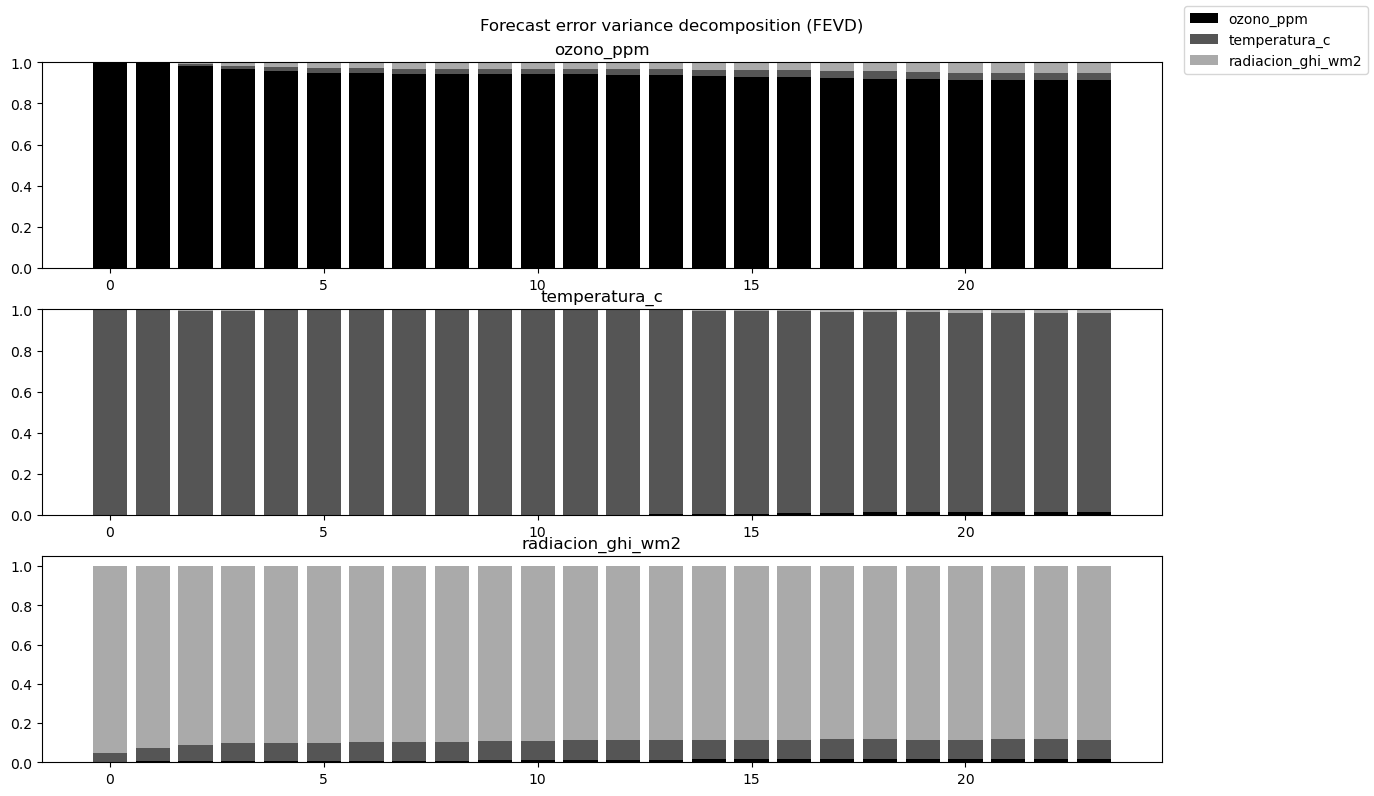

FEVD for ozono_ppm
      ozono_ppm  temperatura_c  radiacion_ghi_wm2
0      1.000000       0.000000           0.000000
1      0.994334       0.002532           0.003134
2      0.980272       0.009300           0.010428
3      0.966572       0.015721           0.017707
4      0.956852       0.019858           0.023290
5      0.950190       0.022570           0.027240
6      0.946160       0.024346           0.029494
7      0.944323       0.025214           0.030463
8      0.944065       0.025329           0.030607
9      0.944265       0.025235           0.030500
10     0.943967       0.025450           0.030583
11     0.942506       0.026374           0.031120
12     0.939795       0.028053           0.032152
13     0.936676       0.029781           0.033542
14     0.933437       0.031427           0.035136
15     0.930403       0.032753           0.036844
16     0.927314       0.033749           0.038937
17     0.923966       0.034515           0.041518
18     0.920512       0.035017 

In [8]:
fevd = resultado.fevd(24)
fevd.plot(figsize=(14, 8))
plt.show()
print(fevd.summary())

## 8. Pronóstico sobre el test y evaluación

Se pronostica sobre las 168 horas de test (en la serie diferenciada) y se invierte la diferencia estacional sumando el valor real de 24 horas antes (`Y[t] = Y_diff_pronosticado[t] + Y_real[t-24]`), para poder comparar contra la serie original y contra el SARIMA de `05_sarima.ipynb`.

[VAR - ozono_ppm] MAE=0.00827  RMSE=0.01096  (sobre 168/168 horas válidas)
[VAR - temperatura_c] MAE=1.06236  RMSE=1.31122  (sobre 168/168 horas válidas)
[VAR - radiacion_ghi_wm2] MAE=34.18000  RMSE=83.50981  (sobre 168/168 horas válidas)


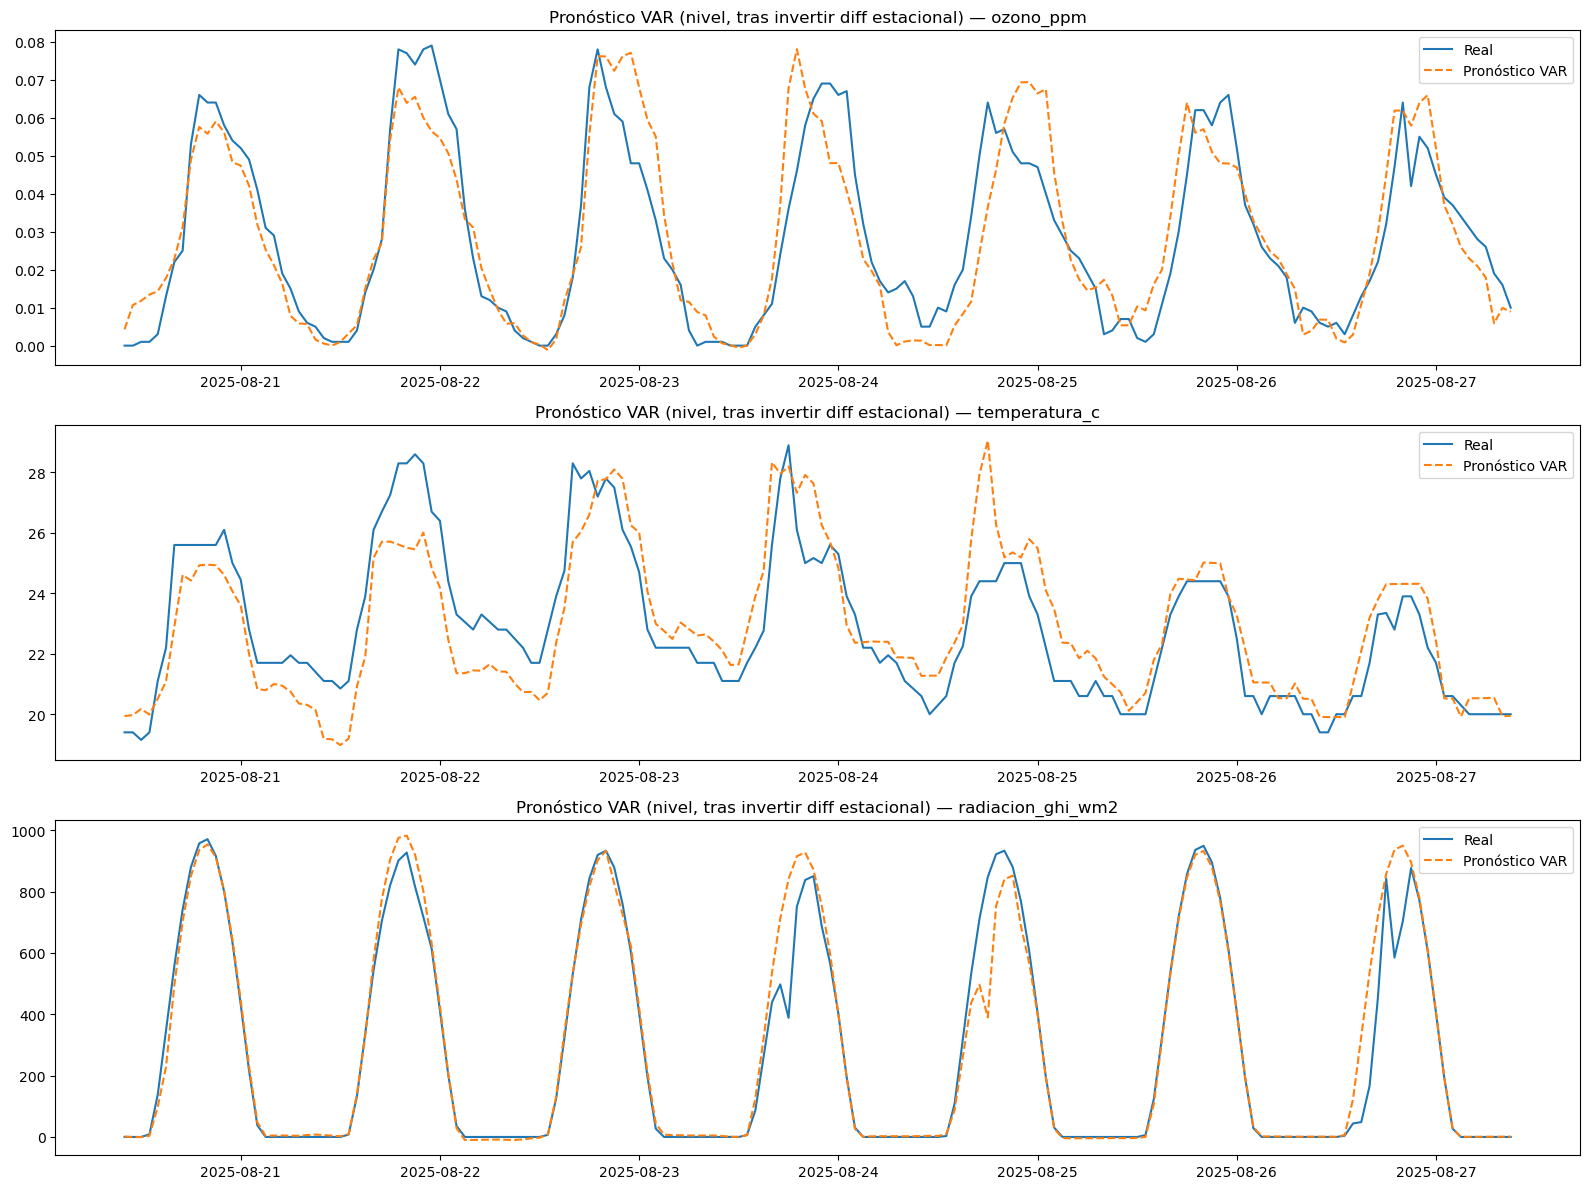

In [9]:
pronostico_diff = resultado.forecast(train.values[-lag_elegido:], steps=HORAS_TEST)
pronostico_diff = pd.DataFrame(pronostico_diff, index=test.index, columns=train.columns)

resultados_var = {}
fig, axes = plt.subplots(len(datos.columns), 1, figsize=(16, 12))

for ax, col in zip(axes, datos.columns):
    base_24h_antes = datos[col].reindex(test.index - pd.Timedelta(hours=PERIODO_ESTACIONAL)).values
    pronostico_nivel = pronostico_diff[col].values + base_24h_antes
    real_nivel = datos[col].reindex(test.index).values

    # Un puñado de horas se descartó en la limpieza (huecos largos); si alguna
    # de las horas necesarias para invertir la diferencia cae ahí, se excluye
    # sólo esa observación de la métrica en vez de invalidar todo el cálculo.
    valido = ~(np.isnan(real_nivel) | np.isnan(pronostico_nivel))
    mae = mean_absolute_error(real_nivel[valido], pronostico_nivel[valido])
    rmse = math.sqrt(mean_squared_error(real_nivel[valido], pronostico_nivel[valido]))
    resultados_var[col] = {"MAE": mae, "RMSE": rmse}
    print(f"[VAR - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}  (sobre {valido.sum()}/{len(valido)} horas válidas)")

    ax.plot(test.index, real_nivel, label="Real")
    ax.plot(test.index, pronostico_nivel, label="Pronóstico VAR", linestyle="--")
    ax.set_title(f"Pronóstico VAR (nivel, tras invertir diff estacional) — {col}")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Comparación con el SARIMA de 05_sarima.ipynb

Mismo período de test (últimos 7 días), para ver si el VAR conjunto mejora o empeora frente a modelar cada serie por separado.

In [10]:
resumen_comparacion = pd.DataFrame(resultados_var).T
resumen_comparacion.index.name = "serie"
print("Métricas del VAR conjunto (nivel, ventana de test = últimas 168 horas):")
print(resumen_comparacion)
print("\nComparar contra las métricas impresas al final de 05_sarima.ipynb (mismo período de test).")

destino = PROJECT_ROOT / "data/processed/resultados_var.json"
destino.write_text(json.dumps({"orden_var": int(lag_elegido), "metricas": resultados_var}, indent=2), encoding="utf-8")
print(f"\nGuardado en {destino}")
print("\nProyecto listo para continuar con 07_pronosticos.ipynb")

Métricas del VAR conjunto (nivel, ventana de test = últimas 168 horas):
                         MAE       RMSE
serie                                  
ozono_ppm           0.008269   0.010956
temperatura_c       1.062356   1.311224
radiacion_ghi_wm2  34.180001  83.509810

Comparar contra las métricas impresas al final de 05_sarima.ipynb (mismo período de test).

Guardado en C:\Series_AMBA\data\processed\resultados_var.json

Proyecto listo para continuar con 07_pronosticos.ipynb
